# From a Fruit Fly Brain Map to an AI Model

You will look at a real fruit-fly wiring map, then **train and test** a small model.

Run the code cells from top to bottom. When a cell says you can change a value, change it and run that cell again.

By the end you should be able to:

1. Read a small map of real neurons and their connections.
2. Use a training example, a prediction, and feedback.
3. Train a model, test it on a held-out example, then reset it and train again.
4. Say what came from the measured map and what this lesson added.

## The data in this notebook

Part 1 uses two small tables from **MaleCNS v1.0**, a published map of one male fruit fly's brain and nerve cord (about 166,700 neurons). `neurons.csv` has 6 of those neurons. `connections.csv` has the 16 measured links among them. Each link's number is a synapse count: how many contacts were mapped from one neuron onto another.

Part 3 trains a separate toy model. Its examples and weights were made for class. They are not rows from the fly map.

### Attribution

The fly measurements are a filtered excerpt of MaleCNS v1.0, licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Values that were kept were not edited. How the six neurons were chosen is in `data/README.md`.

Berg, S., et al. (2026). Sexual dimorphism in the complete connectome of the Drosophila male central nervous system. *Cell*, 189, 5504–5526. https://doi.org/10.1016/j.cell.2026.08.015

Data producers: FlyEM at HHMI Janelia, the University of Cambridge Department of Zoology, the MRC Laboratory of Molecular Biology, and Google Research. This course excerpt does not imply their endorsement.


# 0. Warmup

**What could a map of connections tell a computer to do, and what would a person still have to provide?**


Add your response here:


# 1. Explore the real map

A **neuron** is a nerve cell. A **synapse** is a contact where one neuron can signal another. This map records reconstructed neurons and how many synapses were mapped from one onto another in one preserved male fly.

These six neurons are every MaleCNS v1.0 neuron of type `DNp01` (the giant fibers), `TTMn` (jump motor neurons), or `PSI`. The female FlyWire map is a different project.

Run the next cell. You should see **6 neurons**, **16 connections**, and one diagram. Numbers on the arrows are measured synapse counts.


Neurons: 6
Connections: 16


,body_id,type,instance,status_label,superclass,synonyms
0,10001,DNp01,DNp01(GF)_R,Roughly traced,descending_neuron,Kennedy and Broadie 2018: GF
1,10010,DNp01,DNp01(GF)_L,Roughly traced,descending_neuron,Kennedy and Broadie 2018: GF
2,800146,TTMn,TTMn_R,Reviewed,vnc_motor,
3,802401,PSI,PSI_L,Reviewed,vnc_efferent,
4,804642,TTMn,TTMn_L,Reviewed,vnc_motor,
5,903327,PSI,PSI_R,Reviewed,vnc_efferent,


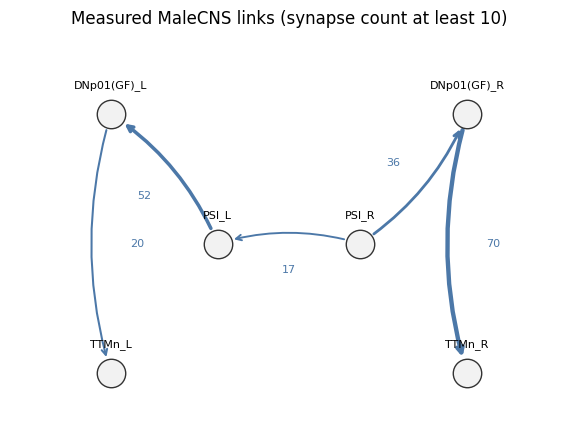

Weaker links are still in the table. The next cell can list every link for one neuron.


In [16]:
# Libraries already used in the other El Camino notebooks.
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def find_csv(name):
    candidates = [
        Path(name),
        Path("data") / name,
        Path("fruit-fly") / "data" / name,
        Path("ecc-ai") / "fruit-fly" / "data" / name,
    ]
    for path in candidates:
        if path.exists():
            return path
    searched = "\n".join("  - " + str(path) for path in candidates)
    raise FileNotFoundError(
        "Could not find " + name + ".\n"
        "Open this notebook from the fruit-fly folder and run this cell again.\n"
        "Looked in:\n" + searched
    )

neurons = pd.read_csv(find_csv("neurons.csv"))
connections = pd.read_csv(find_csv("connections.csv"))
print("Neurons:", len(neurons))
print("Connections:", len(connections))

show_columns = [
    "body_id", "type", "instance", "status_label", "superclass", "synonyms",
]
display(neurons[show_columns].fillna(""))

def draw_real_map(ax):
    positions = {
        "DNp01(GF)_L": (0.0, 2.2),
        "DNp01(GF)_R": (3.0, 2.2),
        "PSI_L": (0.9, 1.1),
        "PSI_R": (2.1, 1.1),
        "TTMn_L": (0.0, 0.0),
        "TTMn_R": (3.0, 0.0),
    }
    # Show the stronger measured links so the picture stays readable.
    drawn = connections[connections["synapse_count"] >= 10]
    for name, (x, y) in positions.items():
        ax.scatter([x], [y], s=420, color="#f2f2f2", edgecolors="#333333", zorder=3)
        ax.text(x, y + 0.2, name, ha="center", va="bottom", fontsize=8)
    for row in drawn.itertuples(index=False):
        x1, y1 = positions[row.pre_instance]
        x2, y2 = positions[row.post_instance]
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops={
                "arrowstyle": "->",
                "color": "#4C78A8",
                "lw": 0.8 + row.synapse_count / 30,
                "connectionstyle": "arc3,rad=0.15",
                "shrinkA": 12,
                "shrinkB": 12,
            },
            zorder=2,
        )
        dx, dy = x2 - x1, y2 - y1
        length = (dx ** 2 + dy ** 2) ** 0.5
        ax.text(
            (x1 + x2) / 2 + (-dy / length) * 0.22,
            (y1 + y2) / 2 + (dx / length) * 0.22,
            str(int(row.synapse_count)),
            color="#4C78A8",
            fontsize=8,
            ha="center",
            va="center",
        )
    ax.set_xlim(-0.85, 3.85)
    ax.set_ylim(-0.5, 2.9)
    ax.set_title("Measured MaleCNS links (synapse count at least 10)")
    ax.axis("off")

fig, ax = plt.subplots(figsize=(7.2, 5.2))
draw_real_map(ax)
plt.show()
print("Weaker links are still in the table. The next cell can list every link for one neuron.")


## Inspect one neuron

Choose a neuron in the menu. Try `DNp01(GF)_R`, then `TTMn_L` or `PSI_L`.

`synapse_count` is the measured number of synapses **from** the first neuron **onto** the second.


In [ ]:
def show_neuron(chosen):
    """Show one neuron and the measured links to and from it."""
    match = neurons[neurons["instance"] == chosen]
    if match.empty:
        print("No neuron is named", chosen)
        print("Choices:", ", ".join(neurons["instance"]))
        return
    display(match[show_columns].fillna(""))
    outgoing = connections[connections["pre_instance"] == chosen].sort_values(
        "synapse_count", ascending=False
    )
    incoming = connections[connections["post_instance"] == chosen].sort_values(
        "synapse_count", ascending=False
    )
    print("Outgoing links from", chosen)
    display(outgoing[["pre_instance", "post_instance", "synapse_count"]])
    print("Incoming links to", chosen)
    display(incoming[["pre_instance", "post_instance", "synapse_count"]])

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    neuron_menu = widgets.Dropdown(
        options=list(neurons["instance"]),
        value="DNp01(GF)_R",
        description="Neuron",
    )
    neuron_out = widgets.Output()

    def refresh_neuron(change=None):
        with neuron_out:
            clear_output(wait=True)
            show_neuron(neuron_menu.value)

    neuron_menu.observe(refresh_neuron, names="value")
    display(widgets.VBox([neuron_menu, neuron_out]))
    refresh_neuron()
except Exception as exc:
    print("The neuron menu is not available in this session.")
    print("Edit chosen, then run this cell again.")
    print("Reason:", type(exc).__name__)
    # Fallback. You can change this name.
    chosen = "DNp01(GF)_R"
    show_neuron(chosen)


## Question 1

Which neuron did you inspect, and what is its strongest outgoing link in this excerpt?


Add your response here:


# 2. Set a task for the model

The map has no labeled trials of "this signal came in, and this response was correct." The links also loop. So the trainable model below is **separate** from the six-neuron map. You will see the measured map again beside the model.

**Invented task.** Two made-up signals can be 0, 1, or 2. The correct response is **jump** (1) or **stay** (0).

| Example set | Correct response in the examples |
|---|---|
| `loom` | Jump when the loom signal is above 0 |
| `odor` | Jump when the odor signal is above 0 |
| `either` | Jump when at least one signal is above 0 |

A **training example** is one row the model is allowed to learn from: the two signals, plus the correct response.

A **held-out example** is a row we keep for the test. Training does not use it.

Run the next cell to see the `loom` rows. You can change `set_name` to `odor` or `either` and run it again.


In [18]:
# Built-in examples. These rows were written for class. They are not fly recordings.
EXAMPLE_SETS = {
    "loom": {
        "train": [
            {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 0, "odor_signal": 1, "correct_response": 0},
            {"loom_signal": 0, "odor_signal": 2, "correct_response": 0},
            {"loom_signal": 1, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
        ],
        "test": [
            {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
        ],
    },
    "odor": {
        "train": [
            {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 1, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 2, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 0, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 0, "odor_signal": 2, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
        ],
        "test": [
            {"loom_signal": 2, "odor_signal": 1, "correct_response": 1},
        ],
    },
    "either": {
        "train": [
            {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
            {"loom_signal": 1, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 0, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 0, "correct_response": 1},
            {"loom_signal": 0, "odor_signal": 2, "correct_response": 1},
            {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
            {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
        ],
        "test": [
            {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
        ],
    },
}

# You can change this to "loom", "odor", or "either".
set_name = "loom"

def response_word(value):
    return "jump" if int(value) == 1 else "stay"

def example_table(rows, predictions=None):
    table = pd.DataFrame(rows)
    table["correct"] = table["correct_response"].map(response_word)
    columns = ["loom_signal", "odor_signal", "correct"]
    if predictions is not None:
        table["prediction"] = [response_word(p) for p in predictions]
        columns.append("prediction")
    return table[columns]

def current_split(name=None):
    name = set_name if name is None else name
    if name == "custom":
        if len(custom_examples) < 2:
            raise ValueError("custom_examples needs at least 2 rows. The last row is held out.")
        return custom_examples[:-1], custom_examples[-1:]
    pack = EXAMPLE_SETS[name]
    return pack["train"], pack["test"]

train_rows, test_rows = current_split()
# Used when set_name is "custom". The edit cell later can replace this list.
# The last row is held out.
custom_examples = [
    {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
    {"loom_signal": 0, "odor_signal": 1, "correct_response": 0},
    {"loom_signal": 0, "odor_signal": 2, "correct_response": 0},
    {"loom_signal": 1, "odor_signal": 0, "correct_response": 1},
    {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
    {"loom_signal": 2, "odor_signal": 0, "correct_response": 1},
    {"loom_signal": 2, "odor_signal": 1, "correct_response": 1},
    {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
    {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
]

print("Example set:", set_name)
print("Training examples the model is allowed to learn from:")
display(example_table(train_rows))
print("Held-out example kept for the test:")
display(example_table(test_rows))


Example set: loom
Training examples the model is allowed to learn from:


,loom_signal,odor_signal,correct
0,0,0,stay
1,0,1,stay
2,0,2,stay
3,1,0,jump
4,1,1,jump
5,2,0,jump
6,2,1,jump
7,2,2,jump


Held-out example kept for the test:


,loom_signal,odor_signal,correct
0,1,2,jump


# 3. Train and test

The model is a **perceptron** with three learned numbers: `w_loom`, `w_odor`, and `bias`. They start at 0.

**Prediction.** Score = `w_loom * loom_signal + w_odor * odor_signal + bias`. The model predicts **jump** when the score is above 0. Otherwise it predicts **stay**.

**Feedback.** Feedback = correct response minus prediction. It is 0 when the prediction already matches, +1 when the model should have said jump, and -1 when it should have said stay. The perceptron changes its weights only when feedback is not 0:

- `w_loom` changes by `feedback * loom_signal`
- `w_odor` changes by `feedback * odor_signal`
- `bias` changes by `feedback`

One **round** is one pass through the training examples. The held-out row is not in those passes.

**Reset** puts the three numbers back to 0. **Train** adds rounds to whatever the weights are now. **Test** checks the held-out row and does not change the weights.


## Question 2

Before you run the test: the weights are all 0, and jump is predicted only when the score is above 0.

What will the untrained model predict for every training example?


Add your prediction here:


Reset. Weights are loom=0, odor=0, bias=0.
Example set: loom
Untrained weights: loom=0, odor=0, bias=0


,loom_signal,odor_signal,correct,prediction
0,0,0,stay,stay
1,0,1,stay,stay
2,0,2,stay,stay
3,1,0,jump,stay
4,1,1,jump,stay
5,2,0,jump,stay
6,2,1,jump,stay
7,2,2,jump,stay


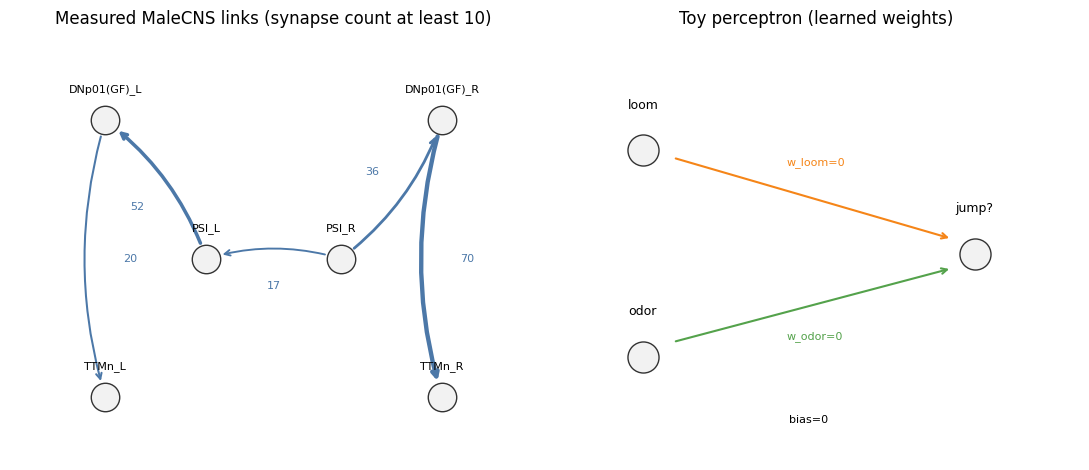

In [9]:
# The learned numbers live in this dictionary. Print `model` any time to see them.
model = {
    "w_loom": 0.0,
    "w_odor": 0.0,
    "bias": 0.0,
    "mistakes_each_round": [],
    "before_predictions": None,
    "trained_on": None,
}

def score_of(row):
    return (
        model["w_loom"] * row["loom_signal"]
        + model["w_odor"] * row["odor_signal"]
        + model["bias"]
    )

def predict_row(row):
    return 1 if score_of(row) > 0 else 0

def reset_model():
    model["w_loom"] = 0.0
    model["w_odor"] = 0.0
    model["bias"] = 0.0
    model["mistakes_each_round"] = []
    model["before_predictions"] = None
    model["trained_on"] = None
    print("Reset. Weights are loom=0, odor=0, bias=0.")

def print_weights(label):
    print(
        label
        + ": loom="
        + format(model["w_loom"], "g")
        + ", odor="
        + format(model["w_odor"], "g")
        + ", bias="
        + format(model["bias"], "g")
    )

def run_baseline():
    train_rows, _ = current_split()
    predictions = [predict_row(row) for row in train_rows]
    model["before_predictions"] = predictions
    print("Example set:", set_name)
    print_weights("Untrained weights")
    display(example_table(train_rows, predictions))

def train_model(n_rounds, learning_rate=1):
    train_rows, _ = current_split()
    if model["before_predictions"] is None or model["trained_on"] != set_name:
        model["before_predictions"] = [predict_row(row) for row in train_rows]
        model["trained_on"] = set_name
    for _ in range(n_rounds):
        wrong = 0
        for row in train_rows:
            prediction = predict_row(row)
            feedback = row["correct_response"] - prediction
            if feedback != 0:
                wrong += 1
                model["w_loom"] += learning_rate * feedback * row["loom_signal"]
                model["w_odor"] += learning_rate * feedback * row["odor_signal"]
                model["bias"] += learning_rate * feedback
        model["mistakes_each_round"].append(wrong)
    print("Trained for", n_rounds, "more rounds on", set_name, "with learning_rate", learning_rate)
    print("Wrong training predictions each round:", model["mistakes_each_round"])
    print_weights("Weights after training")

def draw_toy_model(ax):
    ax.scatter([0.4, 0.4, 2.6], [2.0, 0.6, 1.3], s=500, color="#f2f2f2", edgecolors="#333333", zorder=3)
    ax.text(0.4, 2.28, "loom", ha="center", fontsize=9)
    ax.text(0.4, 0.88, "odor", ha="center", fontsize=9)
    ax.text(2.6, 1.58, "jump?", ha="center", fontsize=9)
    ax.annotate("", xy=(2.45, 1.4), xytext=(0.6, 1.95),
                arrowprops={"arrowstyle": "->", "color": "#F58518", "lw": 1.5})
    ax.annotate("", xy=(2.45, 1.2), xytext=(0.6, 0.7),
                arrowprops={"arrowstyle": "->", "color": "#54A24B", "lw": 1.5})
    ax.text(1.35, 1.9, "w_loom=" + format(model["w_loom"], "g"), color="#F58518", fontsize=8)
    ax.text(1.35, 0.72, "w_odor=" + format(model["w_odor"], "g"), color="#54A24B", fontsize=8)
    ax.text(1.5, 0.15, "bias=" + format(model["bias"], "g"), ha="center", fontsize=8)
    ax.set_xlim(-0.2, 3.3)
    ax.set_ylim(-0.1, 2.8)
    ax.set_title("Toy perceptron (learned weights)")
    ax.axis("off")

def show_charts():
    train_rows, _ = current_split()
    after = [predict_row(row) for row in train_rows]
    before = model["before_predictions"]
    labels = [str(r["loom_signal"]) + "," + str(r["odor_signal"]) for r in train_rows]
    correct = [r["correct_response"] for r in train_rows]
    xs = list(range(len(train_rows)))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    draw_real_map(axes[0])
    draw_toy_model(axes[1])
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].plot(range(1, len(model["mistakes_each_round"]) + 1), model["mistakes_each_round"], marker="o")
    axes[0].set_xlabel("Round")
    axes[0].set_ylabel("Wrong training predictions")
    axes[0].set_title("Training progress")
    axes[0].set_ylim(bottom=0)
    width = 0.25
    axes[1].bar([x - width for x in xs], correct, width=width, label="correct")
    if before is not None and len(before) == len(after):
        axes[1].bar(xs, before, width=width, label="before training")
    axes[1].bar([x + width for x in xs], after, width=width, label="after training")
    axes[1].set_xticks(xs, labels, rotation=45, ha="right")
    axes[1].set_ylim(-0.05, 1.25)
    axes[1].set_ylabel("0 = stay, 1 = jump")
    axes[1].set_title("Training examples")
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    display(example_table(train_rows, after))

def test_held_out():
    _, test_rows = current_split()
    predictions = [predict_row(row) for row in test_rows]
    print("Held-out test for", set_name, "(these rows were not used in Train)")
    display(example_table(test_rows, predictions))
    for row, prediction in zip(test_rows, predictions):
        print(
            "Held-out loom=" + str(row["loom_signal"])
            + " odor=" + str(row["odor_signal"])
            + " correct=" + response_word(row["correct_response"])
            + " prediction=" + response_word(prediction)
        )

# First look: an untrained model beside the measured map.
reset_model()
run_baseline()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
draw_real_map(axes[0])
draw_toy_model(axes[1])
plt.tight_layout()
plt.show()


The left picture is the measured map. Its numbers stay fixed. The right picture is the perceptron before training. Its weights are the learned numbers, and they are 0 right now.

Compare the prediction column with what you wrote in Question 2.


## Train

`n_rounds` is how many passes Train adds. Leave it at 8 for the first run.


Trained for 8 more rounds on loom with learning_rate 1
Wrong training predictions each round: [1, 1, 0, 0, 0, 0, 0, 0]
Weights after training: loom=1, odor=0, bias=0


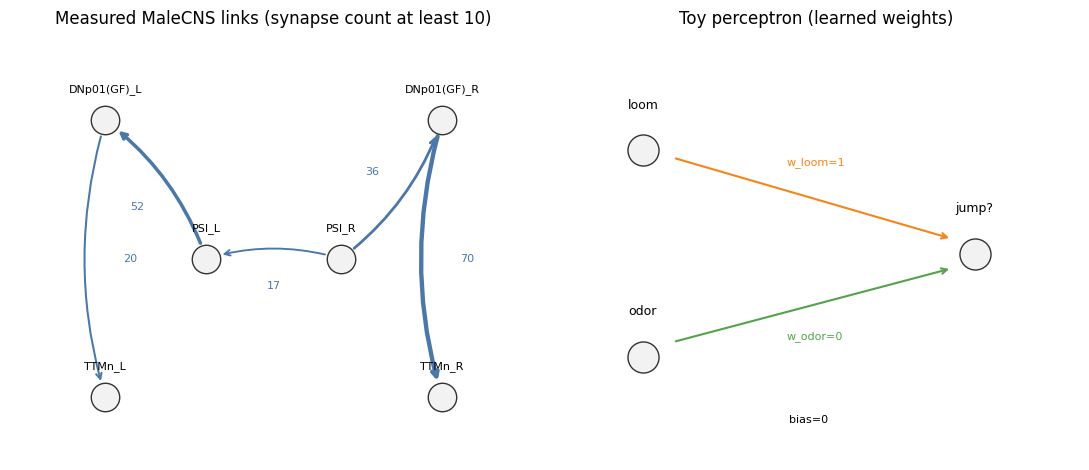

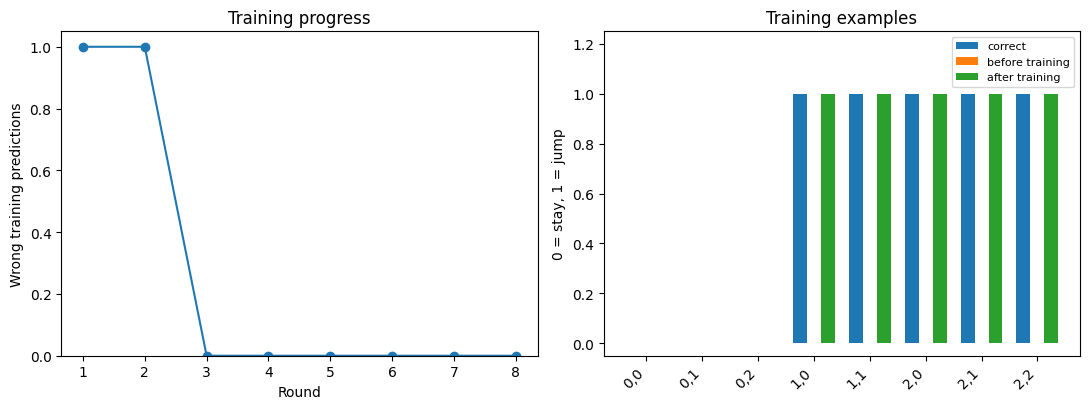

,loom_signal,odor_signal,correct,prediction
0,0,0,stay,stay
1,0,1,stay,stay
2,0,2,stay,stay
3,1,0,jump,jump
4,1,1,jump,jump
5,2,0,jump,jump
6,2,1,jump,jump
7,2,2,jump,jump


In [10]:
# You can change the number of rounds.
n_rounds = 8

train_model(n_rounds)
show_charts()


## Test the held-out example

This row was not in the training passes. Training does not run again in this cell.


In [11]:
test_held_out()


Held-out test for loom (these rows were not used in Train)


,loom_signal,odor_signal,correct,prediction
0,1,2,jump,jump


Held-out loom=1 odor=2 correct=jump prediction=jump


## Switch examples, reset, and train again

The next cell **resets** the weights, then trains on a different built-in set.

Change `set_name` to `"odor"` or `"either"`, then run the cell. Use `"either"` for a second comparison. Pressing Train without Reset would keep the old weights, so this cell resets on purpose.


Reset. Weights are loom=0, odor=0, bias=0.
Example set: odor
Untrained weights: loom=0, odor=0, bias=0


,loom_signal,odor_signal,correct,prediction
0,0,0,stay,stay
1,1,0,stay,stay
2,2,0,stay,stay
3,0,1,jump,stay
4,1,1,jump,stay
5,0,2,jump,stay
6,1,2,jump,stay
7,2,2,jump,stay


Trained for 8 more rounds on odor with learning_rate 1
Wrong training predictions each round: [1, 1, 0, 0, 0, 0, 0, 0]
Weights after training: loom=0, odor=1, bias=0


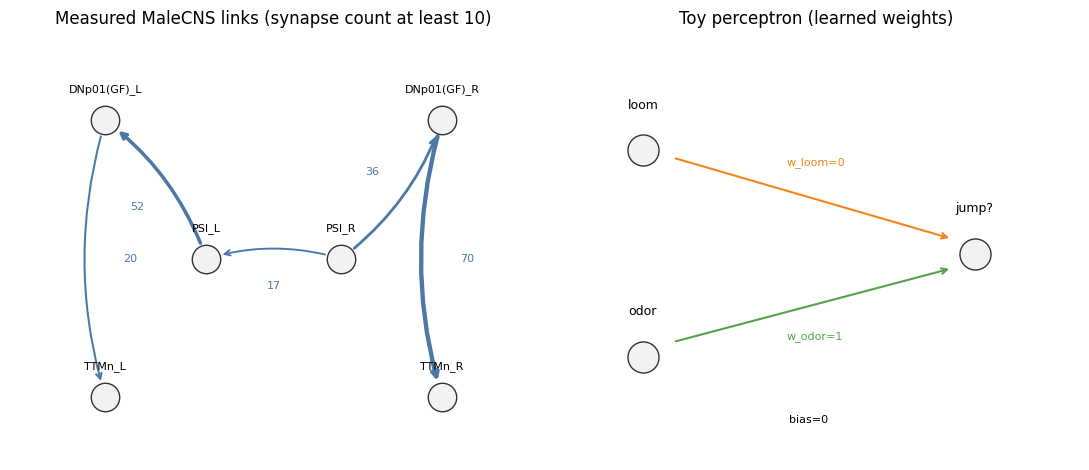

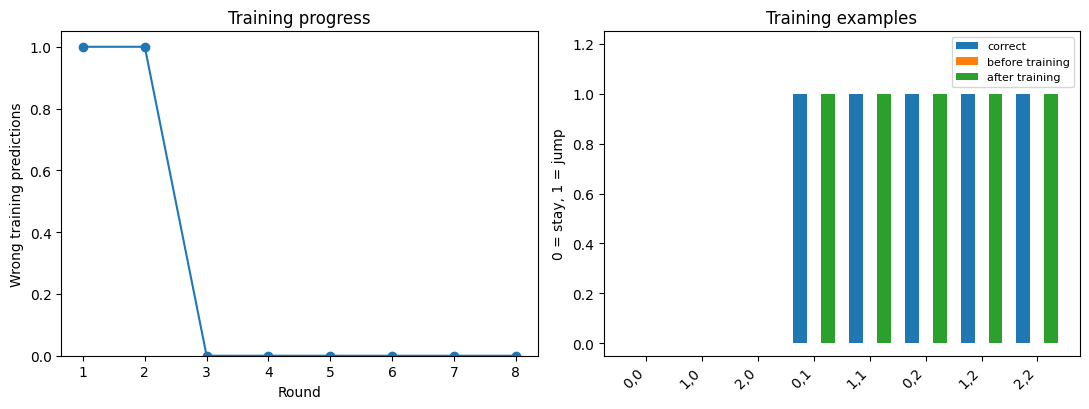

,loom_signal,odor_signal,correct,prediction
0,0,0,stay,stay
1,1,0,stay,stay
2,2,0,stay,stay
3,0,1,jump,jump
4,1,1,jump,jump
5,0,2,jump,jump
6,1,2,jump,jump
7,2,2,jump,jump


Held-out test for odor (these rows were not used in Train)


,loom_signal,odor_signal,correct,prediction
0,2,1,jump,jump


Held-out loom=2 odor=1 correct=jump prediction=jump


In [12]:
# You can change this to "odor" or "either".
set_name = "odor"
n_rounds = 8

reset_model()
run_baseline()
train_model(n_rounds)
show_charts()
test_held_out()


## Edit the feedback

`correct_response` is the feedback's target. The last row in the list is held out. The rows above it are the training examples.

If some training rows are still wrong after a short run, that is not proof the examples are impossible to satisfy. That conclusion fits only when two training rows have the same `loom_signal`, the same `odor_signal`, and opposite `correct_response` values.

The controls below start from the list in the previous cell, with one change: the training row loom 1, odor 0 is set to stay. That edit does **not** create two rows with the same inputs. With 8 rounds and learning rate 1, training does not reach zero mistakes. Move **Rounds** to 11, or set **Learning rate** to 0.2, then press **Check and train** again.

Check **Add opposite label** only when you want the impossible case: a second copy of loom 1, odor 0 with the other response. No weights can make both of those rows correct.

If controls do not appear, edit `flip_stay`, `add_opposite`, `n_rounds`, and `learning_rate` in the code cell and run it again.


Reset. Weights are loom=0, odor=0, bias=0.
Example set: custom
Untrained weights: loom=0, odor=0, bias=0


,loom_signal,odor_signal,correct,prediction
0,0,0,stay,stay
1,0,1,stay,stay
2,0,2,stay,stay
3,1,0,jump,stay
4,1,1,jump,stay
5,2,0,jump,stay
6,2,1,jump,stay
7,2,2,jump,stay


Trained for 8 more rounds on custom with learning_rate 1
Wrong training predictions each round: [1, 1, 0, 0, 0, 0, 0, 0]
Weights after training: loom=1, odor=0, bias=0


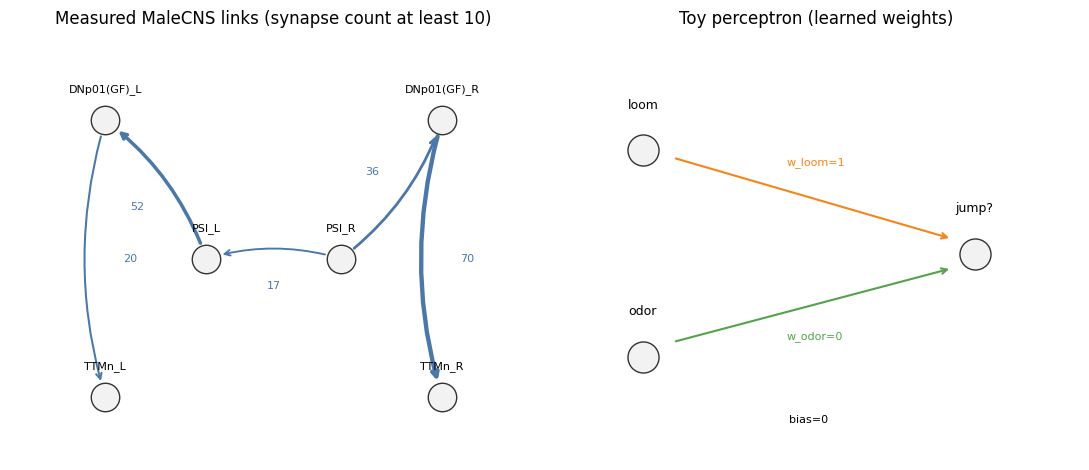

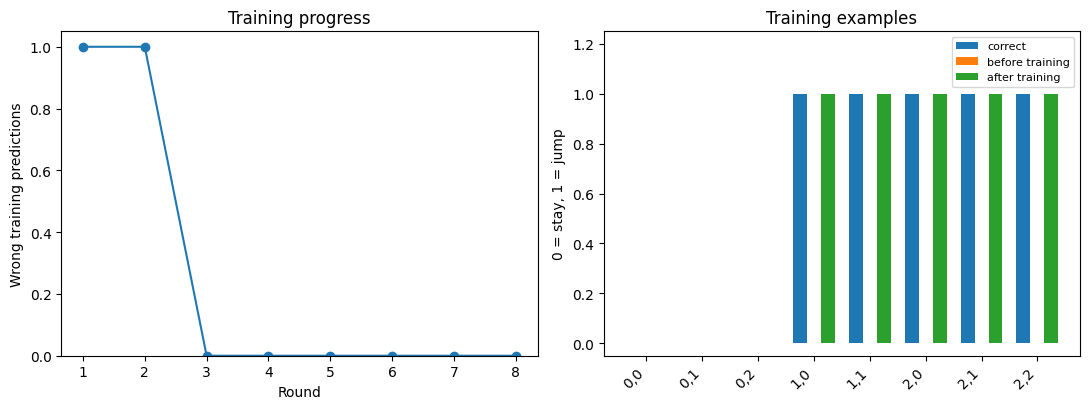

,loom_signal,odor_signal,correct,prediction
0,0,0,stay,stay
1,0,1,stay,stay
2,0,2,stay,stay
3,1,0,jump,jump
4,1,1,jump,jump
5,2,0,jump,jump
6,2,1,jump,jump
7,2,2,jump,jump


Held-out test for custom (these rows were not used in Train)


,loom_signal,odor_signal,correct,prediction
0,1,2,jump,jump


Held-out loom=1 odor=2 correct=jump prediction=jump


In [13]:
# You can edit these rows. The last row is the held-out test.
custom_examples = [
    {"loom_signal": 0, "odor_signal": 0, "correct_response": 0},
    {"loom_signal": 0, "odor_signal": 1, "correct_response": 0},
    {"loom_signal": 0, "odor_signal": 2, "correct_response": 0},
    {"loom_signal": 1, "odor_signal": 0, "correct_response": 1},
    {"loom_signal": 1, "odor_signal": 1, "correct_response": 1},
    {"loom_signal": 2, "odor_signal": 0, "correct_response": 1},
    {"loom_signal": 2, "odor_signal": 1, "correct_response": 1},
    {"loom_signal": 2, "odor_signal": 2, "correct_response": 1},
    {"loom_signal": 1, "odor_signal": 2, "correct_response": 1},
]

set_name = "custom"
n_rounds = 8
learning_rate = 1
reset_model()
run_baseline()
train_model(n_rounds, learning_rate)
show_charts()
test_held_out()


In [ ]:
# Controls for the feedback check. The code under "except" is the fallback.
feedback_base_examples = [dict(row) for row in custom_examples]

def find_opposite_label_pairs(rows):
    pairs = []
    for i in range(len(rows)):
        for j in range(i + 1, len(rows)):
            same_inputs = (
                rows[i]["loom_signal"] == rows[j]["loom_signal"]
                and rows[i]["odor_signal"] == rows[j]["odor_signal"]
            )
            opposite = rows[i]["correct_response"] != rows[j]["correct_response"]
            if same_inputs and opposite:
                pairs.append((i, j))
    return pairs

def examples_for_feedback_check(flip_stay, add_opposite):
    rows = [dict(row) for row in feedback_base_examples]
    if flip_stay:
        for row in rows[:-1]:
            if row["loom_signal"] == 1 and row["odor_signal"] == 0:
                row["correct_response"] = 0
    if add_opposite:
        for row in rows[:-1]:
            if row["loom_signal"] == 1 and row["odor_signal"] == 0:
                opposite = dict(row)
                opposite["correct_response"] = 1 - row["correct_response"]
                rows.insert(-1, opposite)
                break
    return rows

def run_feedback_check(flip_stay, add_opposite, n_rounds, learning_rate):
    global custom_examples, set_name
    saved_examples = custom_examples
    saved_name = set_name
    rows = examples_for_feedback_check(flip_stay, add_opposite)
    custom_examples = rows
    set_name = "custom"
    try:
        train_rows, test_rows = current_split()
        print("Training rows:")
        display(example_table(train_rows))
        print("Held-out row:")
        display(example_table(test_rows))
        pairs = find_opposite_label_pairs(train_rows)
        if pairs:
            print("These training rows have the same loom and odor inputs and opposite correct responses:")
            for i, j in pairs:
                a, b = train_rows[i], train_rows[j]
                print(
                    "  row", i + 1,
                    "loom=" + str(a["loom_signal"]),
                    "odor=" + str(a["odor_signal"]),
                    "correct=" + response_word(a["correct_response"]),
                )
                print(
                    "  row", j + 1,
                    "loom=" + str(b["loom_signal"]),
                    "odor=" + str(b["odor_signal"]),
                    "correct=" + response_word(b["correct_response"]),
                )
            print("No weights can make both rows correct. More rounds or a different learning rate will not fix that.")
            return
        print("No two training rows have the same loom and odor inputs with opposite labels.")
        reset_model()
        train_model(int(n_rounds), learning_rate)
        if model["mistakes_each_round"][-1] != 0:
            print("This run did not reach zero training mistakes in", int(n_rounds), "rounds.")
        else:
            print("Training mistakes reached zero.")
        test_held_out()
    finally:
        custom_examples = saved_examples
        set_name = saved_name

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    flip_box = widgets.Checkbox(value=True, description="Set loom 1, odor 0 to stay")
    opposite_box = widgets.Checkbox(value=False, description="Add opposite label")
    feedback_rounds = widgets.IntSlider(value=8, min=1, max=20, description="Rounds")
    feedback_rate = widgets.Dropdown(
        options=[("1", 1.0), ("0.5", 0.5), ("0.2", 0.2), ("0.1", 0.1)],
        value=1.0,
        description="Learning rate",
    )
    for control in (flip_box, opposite_box, feedback_rounds, feedback_rate):
        control.style.description_width = "14em"
    check_button = widgets.Button(description="Check and train")
    feedback_out = widgets.Output()

    def on_check(_):
        with feedback_out:
            clear_output(wait=True)
            run_feedback_check(
                flip_box.value,
                opposite_box.value,
                feedback_rounds.value,
                feedback_rate.value,
            )

    check_button.on_click(on_check)
    display(widgets.VBox([
        widgets.HTML("<b>Feedback check</b>"),
        flip_box,
        opposite_box,
        feedback_rounds,
        feedback_rate,
        check_button,
        feedback_out,
    ]))
    print("Controls ready. The result below uses the starting choices: edited row, 8 rounds, learning rate 1.")
    run_feedback_check(True, False, 8, 1)
except Exception as exc:
    print("Controls are not available in this session.")
    print("Edit the four values below, then run this cell again.")
    print("Reason:", type(exc).__name__)
    # Fallback values. True edits loom 1, odor 0 from jump to stay.
    flip_stay = True
    add_opposite = False
    n_rounds = 8
    learning_rate = 1
    run_feedback_check(flip_stay, add_opposite, n_rounds, learning_rate)


## Optional buttons

The cells above are the full activity. If buttons appear below, they call the same Reset, Train, and Test steps. Choose an example set, then press **Reset** before **Train** when you want a fresh model. **Test** does not change the weights.


In [14]:
# Buttons, if this Jupyter session has ipywidgets. Otherwise use the cells above.
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    set_menu = widgets.Dropdown(
        options=["loom", "odor", "either", "custom"],
        value="loom",
        description="Examples",
        style={"description_width": "initial"},
    )
    rounds_slider = widgets.IntSlider(
        value=8, min=1, max=20, description="Rounds",
        style={"description_width": "initial"},
    )
    reset_button = widgets.Button(description="Reset")
    train_button = widgets.Button(description="Train")
    test_button = widgets.Button(description="Test")
    button_out = widgets.Output()

    def use_menu_choice():
        global set_name
        set_name = set_menu.value

    def on_reset(_):
        use_menu_choice()
        with button_out:
            clear_output(wait=True)
            reset_model()
            run_baseline()

    def on_train(_):
        use_menu_choice()
        with button_out:
            clear_output(wait=True)
            train_model(int(rounds_slider.value))
            show_charts()

    def on_test(_):
        use_menu_choice()
        with button_out:
            clear_output(wait=True)
            print_weights("Weights used for this test")
            test_held_out()

    reset_button.on_click(on_reset)
    train_button.on_click(on_train)
    test_button.on_click(on_test)
    display(widgets.VBox([
        set_menu,
        rounds_slider,
        widgets.HBox([reset_button, train_button, test_button]),
        button_out,
    ]))
    print("Buttons ready. Reset clears the weights. Train adds rounds. Test checks the held-out row.")
except Exception as exc:
    print("Buttons are not available in this session.")
    print("Use the code cells above: edit set_name or custom_examples, then run Reset, Train, and Test there.")
    print("Reason:", type(exc).__name__)


Buttons ready. Reset clears the weights. Train adds rounds. Test checks the held-out row.


# 4. Reflect

Answer in a few sentences:

1. What did the computer learn when the wrong-answer count fell?
2. What in this notebook came from the measured MaleCNS map?
3. What did we supply as the people writing the lesson?
4. Could this trained model show how a real fly responds? Why or why not?
5. If a model like this were one day used to help choose a medical treatment, what would you want checked first: the measured map, the examples people wrote, or the test on a new example?


Add your response here:


# Sources

- Berg, S., et al. (2026). Sexual dimorphism in the complete connectome of the Drosophila male central nervous system. *Cell*, 189, 5504–5526. https://doi.org/10.1016/j.cell.2026.08.015 — [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). © 2026 MRC Laboratory of Molecular Biology.
- MaleCNS v1.0: https://male-cns.janelia.org/ and https://male-cns.janelia.org/download/
- neuPrint dataset `male-cns:v1.0`: https://neuprint.janelia.org/
- Januszewski, M., and Jain, V. (3 September 2026). A connectomics milestone: Mapping the complete male fruit fly brain. Google Research Blog. https://research.google/blog/a-connectomics-milestone-mapping-the-complete-male-fruit-fly-brain/

The classroom CSV files are the filtered excerpt described in `data/README.md`. The perceptron, its examples, and its weights are not part of that dataset.
